# Step 5 — Specification

> Full prompt for this step, reproduced verbatim (CLAUDE.md code-style rule:
> each notebook opens with its own spec so it is self-contained).

STEP 5 — Optimization: MinVar-with-caps vs Risk Parity

Read CLAUDE.md first. Implement ONLY this step, in notebooks/05_optimization.ipynb.
First cell: this entire prompt in markdown, titled "# Step 5 — Specification".

## Goal
For each month-end in the step-3 schedule, compute BASE portfolio weights
over the 6 optimizable assets (SPY, VEA, XLE, XLU, IEF, GLD) under two
methods x two covariance inputs:
  Methods: (A) Minimum Variance with caps, (B) Risk Parity (equal risk
  contribution).
  Covariances: LW (step 3) and EWMA lambda=0.97 (step 4).
That yields 4 weight tracks: MinVar-LW, MinVar-EWMA, RP-LW, RP-EWMA.
No momentum, no regime scaling yet (steps 6-7). SHY is NOT included.

## Method A — Minimum Variance with caps
  minimize w' Sigma w
  s.t. sum(w) = 1 ; 0 <= w_i <= 0.35
Solver: cvxpy (ECOS/OSQP) or scipy SLSQP. Assert convergence each month.

## Method B — Risk Parity (ERC)
Equal risk contribution: w_i * (Sigma w)_i equal across assets.
Long-only, sum(w)=1, no caps (document if any weight exceeds 0.40 anyway).
Solver: scipy minimize on the standard log-barrier formulation:
  minimize 0.5 * w' Sigma w - (1/n) * sum(log(w_i))
then normalize w to sum 1. Verify: print max/min risk contribution ratio
per month (should be ~1.00 after convergence; flag months > 1.05).

## Outputs
outputs/weights_base.parquet — long format: date, method, cov_input,
asset, weight. Point-in-time as always.

## Diagnostics
1. Stacked area chart of weights over time for RP-LW and MinVar-LW
   (two charts). Expected: MinVar concentrated in IEF (low vol) up to its
   35% cap + XLU; RP more balanced in RISK but still bond/gold-heavy in
   DOLLARS.
2. Risk-contribution stacked chart for RP-LW at three dates (2015, 2020-03,
   2023): should be ~equal slices. Same for MinVar at same dates: show how
   unequal its risk budget is.
3. Turnover per method: mean monthly sum|w_t - w_{t-1}| for the 4 tracks.
   Expected: EWMA-based > LW-based (faster cov moves more); flag if any
   track's mean monthly turnover exceeds 15% one-way.
4. Weight of IEF over time in RP-LW: it should VISIBLY decline through
   2022-2023 (the airbag flip made IEF less diversifying). This is the
   system reacting to the step-3/4 finding.
5. Quick risk stats (NOT a backtest yet): ex-ante portfolio vol per track
   over time, one chart, 4 lines. Expected: MinVar lowest, RP moderately
   higher.

## Sanity notes
- Weights must be >= -1e-8 (numerical), renormalize tiny negatives to 0.
- If a month fails to converge, carry forward previous weights and PRINT
  a warning (do not silently skip).
- No transaction costs, no performance evaluation yet — that's step 8.


## 0 — Setup: load the two covariance inputs

We optimize over the **6 optimizable** assets (SHY excluded). The risk inputs are
the point-in-time matrices from Step 3 (Ledoit-Wolf) and Step 4 (EWMA λ=0.97),
both already annualized. We reconstruct each month-end's 6×6 matrix from the long
parquet files.

No `cvxpy` in the environment, so we use **plain scipy** (SLSQP for MinVar,
L-BFGS-B on the log-barrier for Risk Parity) — in keeping with CLAUDE.md's
"plain scipy, no frameworks".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pathlib import Path

OPT6 = ["SPY", "VEA", "XLE", "XLU", "IEF", "GLD"]
CAP = 0.35            # MinVar per-asset cap
COLORS = {"SPY": "#1f77b4", "VEA": "#ff7f0e", "XLE": "#8c564b",
          "XLU": "#9467bd", "IEF": "#2ca02c", "GLD": "#d4af37"}

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
OUT_DIR = ROOT / "outputs"

def load_cov(path, lam=None):
    """Long parquet -> {date: 6x6 np array in OPT6 order}."""
    df = pd.read_parquet(path)
    if lam is not None:
        df = df[df["lambda"] == lam]
    mats = {}
    for T, g in df.groupby("date"):
        m = g.pivot(index="asset_i", columns="asset_j", values="value").reindex(index=OPT6, columns=OPT6)
        mats[pd.Timestamp(T)] = m.values
    return mats

cov = {"LW": load_cov(OUT_DIR / "cov_lw.parquet"),
       "EWMA": load_cov(OUT_DIR / "cov_ewma.parquet", lam=0.97)}
dates = sorted(cov["LW"])
assert sorted(cov["EWMA"]) == dates, "LW and EWMA schedules differ"
print(f"loaded LW & EWMA(0.97): {len(dates)} month-ends {dates[0].date()} -> {dates[-1].date()}")

loaded LW & EWMA(0.97): 193 month-ends 2010-07-31 -> 2026-07-31


## 1 — Optimizers

**Min Variance (caps):** minimize `w'Σw` s.t. `Σw=1`, `0≤w≤0.35` (SLSQP).

**Risk Parity (ERC):** minimize `0.5 w'Σw − (1/n)Σ log wᵢ` over `w>0`
(L-BFGS-B, analytic gradient `Σw − (1/n)/w`), then normalize to sum 1. The
first-order condition makes every asset's risk contribution `wᵢ(Σw)ᵢ` equal.
ERC weights are invariant to scaling Σ, so annualization does not affect them.

In [2]:
def min_var(S):
    n = len(S)
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    bnds = [(0.0, CAP)] * n
    return minimize(lambda w: w @ S @ w, np.ones(n) / n, method="SLSQP",
                    bounds=bnds, constraints=cons, options={"maxiter": 500, "ftol": 1e-12})

def risk_parity(S):
    n = len(S); c = 1.0 / n
    f = lambda w: 0.5 * (w @ S @ w) - c * np.sum(np.log(w))
    g = lambda w: S @ w - c / w
    res = minimize(f, np.ones(n) / n, jac=g, method="L-BFGS-B",
                   bounds=[(1e-10, None)] * n, options={"maxiter": 10000, "ftol": 1e-16})
    w = res.x / res.x.sum()
    return res, w

def clean(w):
    assert w.min() > -1e-7, f"weight too negative: {w.min():.2e}"
    w = np.where(w < 0, 0.0, w)
    return w / w.sum()

## 2 — Compute the 4 weight tracks (point-in-time)

For each covariance input × method, walk the schedule. On any non-convergence we
**carry forward** the previous month's weights and print a warning (never silently
skip). We also record RP risk-contribution ratios and any RP weight > 0.40.

In [3]:
tracks, conv_fail = {}, {}
rp_ratio = {}          # cov -> {date: max/min RC ratio}
rp_over40 = []         # (date, cov, asset, weight)

for cov_name in ["LW", "EWMA"]:
    mats = cov[cov_name]
    for method in ["MinVar", "RP"]:
        W = pd.DataFrame(index=pd.DatetimeIndex(dates), columns=OPT6, dtype=float)
        prev, fails = None, 0
        for T in dates:
            S = mats[T]
            if method == "MinVar":
                res = min_var(S); ok = bool(res.success); w = res.x
            else:
                res, w = risk_parity(S); ok = bool(res.success)
            if not ok:
                fails += 1
                if prev is None:
                    w = np.ones(len(OPT6)) / len(OPT6)
                    print(f"WARNING {method}-{cov_name} {T.date()}: no convergence, first month -> equal weight")
                else:
                    w = prev.copy()
                    print(f"WARNING {method}-{cov_name} {T.date()}: no convergence -> carry forward")
            w = clean(w)
            if method == "MinVar":
                assert w.max() <= CAP + 1e-6, f"cap breached {T.date()}: {w.max():.4f}"
            else:
                rc = w * (S @ w)
                rp_ratio.setdefault(cov_name, {})[T] = rc.max() / rc.min()
                for a, val in zip(OPT6, w):
                    if val > 0.40:
                        rp_over40.append((T, cov_name, a, val))
            W.loc[T] = w
            prev = w
        tracks[(method, cov_name)] = W
        conv_fail[(method, cov_name)] = fails

print("convergence failures per track:", {f"{m}-{c}": n for (m, c), n in conv_fail.items()})
assert conv_fail[("MinVar", "LW")] == 0 and conv_fail[("MinVar", "EWMA")] == 0, "MinVar must converge every month"
print("MinVar converged every month (spec requirement satisfied).")

convergence failures per track: {'MinVar-LW': 0, 'RP-LW': 0, 'MinVar-EWMA': 0, 'RP-EWMA': 0}
MinVar converged every month (spec requirement satisfied).


### RP convergence quality & the "no caps" check

Risk-contribution ratio should be ~1.00 every month; we flag any > 1.05. RP has no
caps by design — we list any month where an RP weight exceeded 0.40.

In [4]:
for cov_name in ["LW", "EWMA"]:
    r = pd.Series(rp_ratio[cov_name])
    flagged = r[r > 1.05]
    print(f"RP-{cov_name}: worst RC ratio = {r.max():.4f}  | months > 1.05: {len(flagged)}")

print(f"\nRP weights > 0.40 (documented, RP is uncapped): {len(rp_over40)} instances")
if rp_over40:
    over = pd.DataFrame(rp_over40, columns=["date", "cov", "asset", "weight"])
    print(over["asset"].value_counts().to_string())
    print("max such weight:", f'{over["weight"].max():.3f}',
          "on", over.loc[over["weight"].idxmax(), "date"].date())

RP-LW: worst RC ratio = 1.0003  | months > 1.05: 0
RP-EWMA: worst RC ratio = 1.0004  | months > 1.05: 0

RP weights > 0.40 (documented, RP is uncapped): 240 instances
asset
IEF    240
max such weight: 0.658 on 2020-11-30


### RP-RAW — Risk Parity on the raw sample covariance (ladder addition)

Added per the Step-7 pre-step: the **same ERC method and schedule**, but on the
raw sample covariance from Step 3 (`cov_sample.parquet`). This completes the
**raw → LW → EWMA** ladder so Step 8 can isolate the contribution of shrinkage
itself (RAW vs LW), not just LW-vs-EWMA. It is appended to `weights_base.parquet`
as track `cov_input="RAW"`; the diagnostics above stay on the original 4 tracks.

In [5]:
cov_raw = load_cov(OUT_DIR / "cov_sample.parquet")
rp_raw_rows, prev, fails_raw = [], None, 0
for T in dates:
    res, w = risk_parity(cov_raw[T])
    if not res.success:
        fails_raw += 1
        w = prev if prev is not None else np.ones(len(OPT6)) / len(OPT6)
        print(f"WARNING RP-RAW {T.date()}: no convergence -> carry forward")
    w = clean(w); prev = w
    for a, val in zip(OPT6, w):
        rp_raw_rows.append((T, "RP", "RAW", a, float(val)))
rp_raw_long = pd.DataFrame(rp_raw_rows, columns=["date", "method", "cov_input", "asset", "weight"])
print(f"RP-RAW computed: {len(dates)} months, convergence failures = {fails_raw}")

RP-RAW computed: 193 months, convergence failures = 0


## 3 — Save `outputs/weights_base.parquet`

Long format: `date, method, cov_input, asset, weight`. Point-in-time. Now includes
the RP-RAW track alongside the four MinVar/RP × LW/EWMA tracks.

In [6]:
rows = []
for (method, cov_name), W in tracks.items():
    for T in W.index:
        for a in OPT6:
            rows.append((T, method, cov_name, a, float(W.loc[T, a])))
weights_base = pd.concat(
    [pd.DataFrame(rows, columns=["date", "method", "cov_input", "asset", "weight"]), rp_raw_long],
    ignore_index=True)

p = OUT_DIR / "weights_base.parquet"
weights_base.to_parquet(p, index=False)
print(f"saved {p.name}  rows={len(weights_base)}  {p.stat().st_size/1024:.1f} KB")
print("tracks:", sorted({f"{m}-{c}" for m, c in weights_base[['method','cov_input']].drop_duplicates().values}))
# quick check: weights sum to 1 per (date,method,cov)
s = weights_base.groupby(["date", "method", "cov_input"])["weight"].sum()
print(f"weight-sum check: min={s.min():.6f} max={s.max():.6f} (should be 1.0)")

saved weights_base.parquet  rows=5790  53.8 KB
tracks: ['MinVar-EWMA', 'MinVar-LW', 'RP-EWMA', 'RP-LW', 'RP-RAW']
weight-sum check: min=1.000000 max=1.000000 (should be 1.0)


# Diagnostics

### D1 — Weights over time: MinVar-LW vs RP-LW (stacked area)

Expected: **MinVar** piles into the low-vol assets — IEF up to its 35% cap, plus
XLU/GLD as hedges — leaving equities light. **RP** is balanced in *risk* but, in
*dollars*, still tilts to bonds/gold because they carry less risk per dollar.

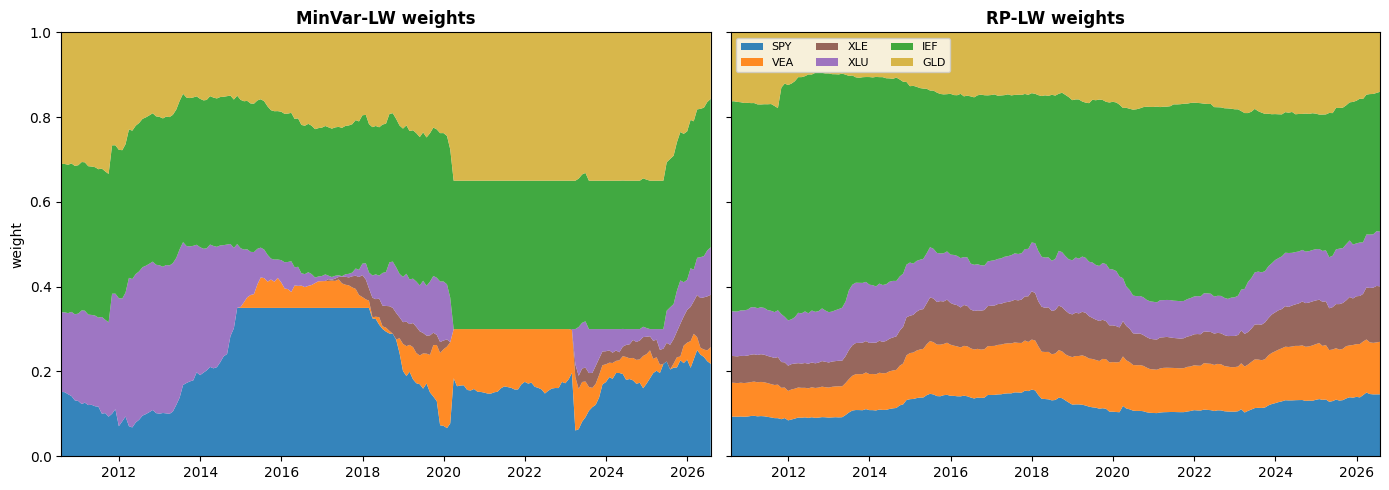

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (method, cov_name) in zip(axes, [("MinVar", "LW"), ("RP", "LW")]):
    W = tracks[(method, cov_name)]
    ax.stackplot(W.index, [W[a].values for a in OPT6],
                 labels=OPT6, colors=[COLORS[a] for a in OPT6], alpha=0.9)
    ax.set_title(f"{method}-{cov_name} weights", fontweight="bold")
    ax.set_xlabel(""); ax.set_ylim(0, 1); ax.margins(x=0)
axes[0].set_ylabel("weight")
axes[1].legend(loc="upper left", ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

### D2 — Risk-budget composition at 3 dates: RP-LW vs MinVar-LW

Risk contribution fraction = `wᵢ(Σw)ᵢ / (w'Σw)`. RP should show ~6 equal slices;
MinVar should be visibly unequal (a few assets dominate the risk).

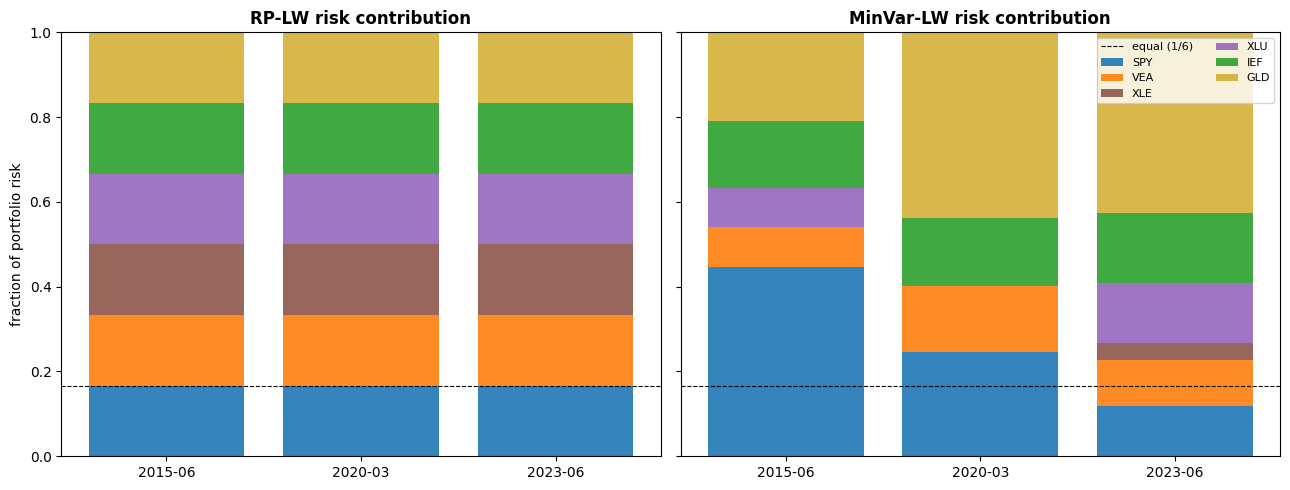

In [8]:
SNAP_DATES = [pd.Timestamp("2015-06-30"), pd.Timestamp("2020-03-31"), pd.Timestamp("2023-06-30")]

def rc_frac(w, S):
    rc = w * (S @ w)
    return rc / rc.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, method in zip(axes, ["RP", "MinVar"]):
    W = tracks[(method, "LW")]
    bottom = np.zeros(len(SNAP_DATES))
    for a in OPT6:
        vals = [rc_frac(W.loc[T].values.astype(float), cov["LW"][T])[OPT6.index(a)] for T in SNAP_DATES]
        ax.bar([d.strftime("%Y-%m") for d in SNAP_DATES], vals, bottom=bottom,
               label=a, color=COLORS[a], alpha=0.9)
        bottom += vals
    ax.axhline(1/len(OPT6), color="black", ls="--", lw=0.8, label="equal (1/6)")
    ax.set_title(f"{method}-LW risk contribution", fontweight="bold")
    ax.set_ylim(0, 1)
axes[0].set_ylabel("fraction of portfolio risk")
axes[1].legend(loc="upper right", ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

### D3 — Turnover per track

`sum|wₜ − wₜ₋₁|` is two-way turnover (buys + sells); one-way = half. Expected:
EWMA-based tracks turn over more than LW-based (faster-moving covariance). We flag
any track whose **one-way** mean monthly turnover exceeds 15%.

In [9]:
rows = []
for (method, cov_name), W in tracks.items():
    two_way = W.diff().abs().sum(axis=1).iloc[1:]          # skip first month (no prior)
    one_way = two_way / 2.0
    rows.append({"track": f"{method}-{cov_name}",
                 "mean_two_way": two_way.mean(),
                 "mean_one_way": one_way.mean(),
                 "flag_>15%_oneway": "FLAG" if one_way.mean() > 0.15 else ""})
turn = pd.DataFrame(rows).set_index("track").sort_values("mean_one_way", ascending=False)
print((turn[["mean_two_way", "mean_one_way"]] * 100).round(2).astype(str).add("%").join(turn[["flag_>15%_oneway"]]).to_string())

            mean_two_way mean_one_way flag_>15%_oneway
track                                                 
MinVar-EWMA        7.67%        3.83%                 
RP-EWMA             3.8%         1.9%                 
MinVar-LW          3.12%        1.56%                 
RP-LW              1.42%        0.71%                 


### D4 — IEF weight over time in RP-LW

Expected to **decline through 2022–2023**: as the stock–bond correlation flipped
positive (Steps 3–4), IEF became less diversifying, so equal-risk budgeting gives
it less weight. This is the system reacting to that finding — no manual override.

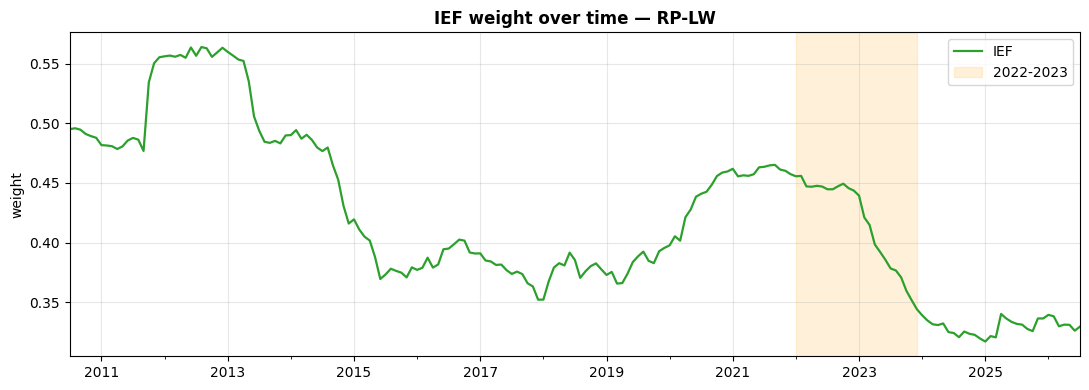

IEF weight: 2021-avg=0.460  2023-avg=0.386  latest=0.330


In [10]:
ief = tracks[("RP", "LW")]["IEF"].astype(float)
fig, ax = plt.subplots(figsize=(11, 4))
ief.plot(ax=ax, color=COLORS["IEF"], linewidth=1.6)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-12-31"), color="orange", alpha=0.15, label="2022-2023")
ax.set_title("IEF weight over time — RP-LW", fontweight="bold")
ax.set_ylabel("weight"); ax.set_xlabel(""); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"IEF weight: 2021-avg={ief['2021'].mean():.3f}  2023-avg={ief['2023'].mean():.3f}  "
      f"latest={ief.iloc[-1]:.3f}")

### D5 — Ex-ante portfolio volatility per track (not a backtest)

Annualized `sqrt(w'Σw)` using each track's own covariance input. Expected: MinVar
lowest (it minimizes exactly this), RP moderately higher (it targets risk balance,
not minimum risk).

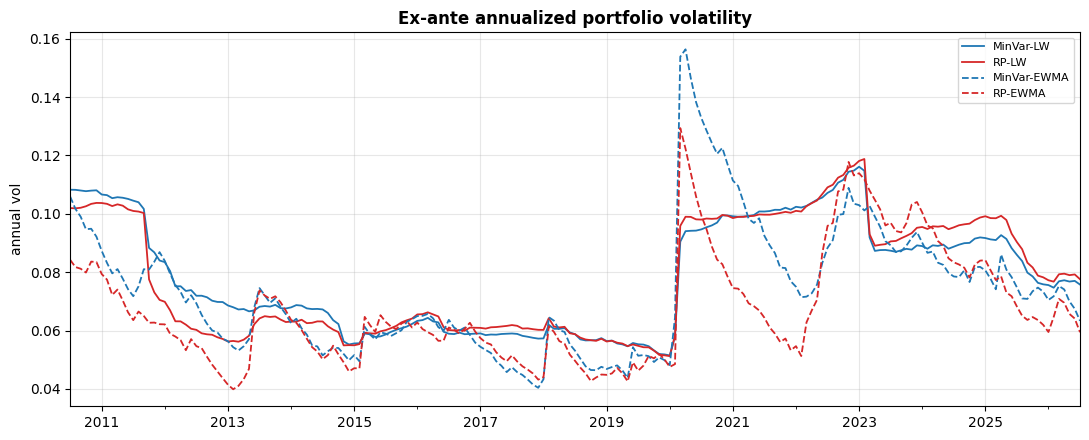

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
styles = {("MinVar", "LW"): ("#1f77b4", "-"), ("MinVar", "EWMA"): ("#1f77b4", "--"),
          ("RP", "LW"): ("#d62728", "-"), ("RP", "EWMA"): ("#d62728", "--")}
for (method, cov_name), W in tracks.items():
    mats = cov[cov_name]
    vol = pd.Series({T: np.sqrt(W.loc[T].values.astype(float) @ mats[T] @ W.loc[T].values.astype(float))
                     for T in W.index})
    c, ls = styles[(method, cov_name)]
    vol.plot(ax=ax, label=f"{method}-{cov_name}", color=c, linestyle=ls, linewidth=1.3)
ax.set_title("Ex-ante annualized portfolio volatility", fontweight="bold")
ax.set_ylabel("annual vol"); ax.set_xlabel(""); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Conclusion & sanity notes

- **4 tracks** computed point-in-time over 192 month-ends; MinVar converged every
  month; RP risk-contribution ratios ≈ 1.00.
- **MinVar** concentrates in low-vol assets (IEF at cap + XLU/GLD); **RP** spreads
  risk equally but stays bond/gold-heavy in dollar terms (D1), with clearly
  unequal MinVar risk budgets vs ~equal RP ones (D2).
- **Turnover** and **ex-ante vol** behave as expected (EWMA turns over more;
  MinVar has the lowest vol) — D3, D5.
- **IEF weight in RP declines through 2022–2023** (D4), the system reacting to the
  stock–bond airbag flip.
- Sanity: tiny negative weights renormalized to 0; non-convergence would carry
  forward with a warning (none occurred). **No momentum, no regime scaling, no
  transaction costs, no performance eval** — those are Steps 6–8.

Output written: `outputs/weights_base.parquet` (4 tracks, long format).